# Stage 1 LipVoicer Evaluation Notebook

This notebook is **Stage 1 only** (lip ROI to text). It helps you:

1. Wire up a LipVoicer-style Stage 1 CNN/sequence model.
2. Load official LipVoicer lip-reading weights when available.
3. Evaluate on this repository's `val.tsv` split using `mouth_rois` from `.npz`.
4. Decide: reuse pretrained, fine-tune, or retrain.

## Repository assumptions

- Python 3.12 environment
- `uv` + `.venv` workflow
- Existing data artifacts under `data/dataset_final` and `data/lip_rois`

## Outline

1. Environment Setup and Reproducibility
2. Stage 1 Data Contract Loader (ROI + Tokens)
3. LipVoicer Checkpoint Discovery and Model Construction
4. Pretrained Weights Loading and Compatibility Checks
5. Inference Pipeline (Greedy/Beam CTC Decode)
6. Baseline Evaluation on Validation Split (WER/CER)
7. Confidence Score Extraction and Calibration
8. Error Bucketing for Stage 1 Failures
9. Quick Fine-Tuning Experiment (Optional)
10. Retrain-vs-Reuse Decision Matrix and Next Actions

## 1. Environment Setup and Reproducibility

This section installs/imports required packages, sets deterministic behavior, chooses device, and defines global paths/config.

If this is a fresh setup, run the `uv` commands in your terminal first:

```bash
uv venv .venv --python 3.12
source .venv/bin/activate
uv pip install torch torchvision torchaudio pandas numpy jiwer matplotlib scikit-learn tqdm
```

Then continue in this notebook.

In [2]:
import os
import re
import json
import math
import time
import random
import subprocess
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

try:
    import jiwer
except ImportError as exc:
    raise ImportError("Please install jiwer: uv pip install jiwer") from exc

try:
    from sklearn.isotonic import IsotonicRegression
except Exception:
    IsotonicRegression = None

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("Python:", os.sys.version.split()[0])

ROOT = Path('/home/shra012/Data255-Project')
DATA_DIR = ROOT / 'data' / 'dataset_final'
LIP_ROI_DIR = ROOT / 'data' / 'lip_rois'
OUTPUT_DIR = ROOT / 'outputs' / 'stage1_eval'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "batch_size": 4,
    "num_workers": 2,
    "max_train_samples": None,
    "max_val_samples": 120,
    "decode_mode": "greedy",  # greedy | beam
    "beam_width": 8,
    "clone_lipvoicer_repo": True,
    "download_lipvoicer_checkpoints": False,
    "lipvoicer_repo_dir": ROOT / 'third_party' / 'LipVoicer',
    "local_checkpoint_candidates": [
        ROOT / 'checkpoints' / 'stage1_lipreading.pt',
        ROOT / 'checkpoints' / 'stage1_lipreading.pth',
    ],
}

def to_jsonable(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [to_jsonable(v) for v in obj]
    return obj

print(json.dumps(to_jsonable(CONFIG), indent=2))

ModuleNotFoundError: No module named 'numpy'

## 2. Stage 1 Data Contract Loader (ROI + Tokens)

This section enforces the data contract and builds train/val dataloaders:

- Required keys: `clip_id`, `text`, `speaker_id`
- ROI source: `data/lip_rois/{speaker_id}/{clip_id}.npz`
- ROI tensor shape assertion: `(T, 96, 96)` from `mouth_rois`
- Tokens: character-level IDs with `<blank>` reserved for CTC

In [11]:
def read_manifest(tsv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(tsv_path, sep='\t', engine='python')
    df.columns = [c.strip() for c in df.columns]
    required = {'clip_id', 'text', 'speaker_id'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in {tsv_path}: {missing}")
    for col in ['clip_id', 'text', 'speaker_id']:
        df[col] = df[col].astype(str).str.strip()
    return df

train_df = read_manifest(DATA_DIR / 'train.tsv')
val_df = read_manifest(DATA_DIR / 'val.tsv')
test_df = read_manifest(DATA_DIR / 'test.tsv')

print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))

if CONFIG['max_train_samples']:
    train_df = train_df.head(CONFIG['max_train_samples']).copy()
if CONFIG['max_val_samples']:
    val_df = val_df.head(CONFIG['max_val_samples']).copy()

all_text = pd.concat([train_df['text'], val_df['text']], axis=0).tolist()
charset = sorted({ch for text in all_text for ch in text.lower()})

# CTC blank token is index 0
idx_to_token = ['<blank>'] + charset
token_to_idx = {tok: i for i, tok in enumerate(idx_to_token)}
blank_id = token_to_idx['<blank>']

print('Vocab size (incl blank):', len(idx_to_token))


def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r'\s+', ' ', s)
    return s


def encode_text(s: str) -> List[int]:
    s = normalize_text(s)
    return [token_to_idx[ch] for ch in s if ch in token_to_idx]


def decode_ids(ids: List[int]) -> str:
    chars = []
    for i in ids:
        if i == blank_id:
            continue
        if 0 <= i < len(idx_to_token):
            chars.append(idx_to_token[i])
    return ''.join(chars).strip()


class Stage1Dataset(Dataset):
    def __init__(self, manifest: pd.DataFrame, lip_roi_dir: Path):
        self.df = manifest.reset_index(drop=True)
        self.lip_roi_dir = lip_roi_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        clip_id = row['clip_id']
        speaker_id = row['speaker_id']
        text = normalize_text(row['text'])

        roi_path = self.lip_roi_dir / speaker_id / f'{clip_id}.npz'
        if not roi_path.exists():
            raise FileNotFoundError(f'ROI file missing: {roi_path}')

        npz = np.load(roi_path)
        if 'mouth_rois' not in npz.files:
            raise KeyError(f"'mouth_rois' missing in {roi_path}")

        rois = npz['mouth_rois']  # (T, 96, 96)
        assert rois.ndim == 3, f'Expected 3D mouth_rois, got {rois.shape}'
        assert rois.shape[1:] == (96, 96), f'Expected (T,96,96), got {rois.shape}'

        rois = rois.astype(np.float32) / 255.0
        rois = torch.from_numpy(rois).unsqueeze(0)  # (1, T, 96, 96)

        token_ids = encode_text(text)
        if len(token_ids) == 0:
            token_ids = [blank_id]

        sample = {
            'clip_id': clip_id,
            'speaker_id': speaker_id,
            'roi_path': str(roi_path),
            'rois': rois,
            'roi_len': rois.shape[1],
            'text': text,
            'token_ids': torch.tensor(token_ids, dtype=torch.long),
            'token_len': len(token_ids),
        }
        return sample


def collate_stage1(batch: List[Dict]):
    bsz = len(batch)
    max_t = max(item['roi_len'] for item in batch)
    max_u = max(item['token_len'] for item in batch)

    rois = torch.zeros((bsz, 1, max_t, 96, 96), dtype=torch.float32)
    roi_lens = torch.zeros((bsz,), dtype=torch.long)

    token_ids = torch.full((bsz, max_u), fill_value=blank_id, dtype=torch.long)
    token_lens = torch.zeros((bsz,), dtype=torch.long)

    clip_ids, speaker_ids, texts, roi_paths = [], [], [], []

    for i, item in enumerate(batch):
        t = item['roi_len']
        u = item['token_len']
        rois[i, :, :t] = item['rois']
        roi_lens[i] = t
        token_ids[i, :u] = item['token_ids']
        token_lens[i] = u
        clip_ids.append(item['clip_id'])
        speaker_ids.append(item['speaker_id'])
        texts.append(item['text'])
        roi_paths.append(item['roi_path'])

    roi_mask = torch.arange(max_t).unsqueeze(0) < roi_lens.unsqueeze(1)

    return {
        'clip_id': clip_ids,
        'speaker_id': speaker_ids,
        'roi_path': roi_paths,
        'rois': rois,
        'roi_lens': roi_lens,
        'roi_mask': roi_mask,
        'text': texts,
        'token_ids': token_ids,
        'token_lens': token_lens,
    }


train_ds = Stage1Dataset(train_df, LIP_ROI_DIR)
val_ds = Stage1Dataset(val_df, LIP_ROI_DIR)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    collate_fn=collate_stage1,
)
val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    collate_fn=collate_stage1,
)

example = next(iter(val_loader))
print('Batch rois:', tuple(example['rois'].shape))
print('Batch token_ids:', tuple(example['token_ids'].shape))
print('ROI lengths:', example['roi_lens'][:4].tolist())
print('Token lengths:', example['token_lens'][:4].tolist())

train: 101 val: 75 test: 108
Vocab size (incl blank): 39
Batch rois: (4, 1, 109, 96, 96)
Batch token_ids: (4, 57)
ROI lengths: [65, 109, 54, 63]
Token lengths: [35, 57, 39, 49]


## 3. LipVoicer Checkpoint Discovery and Model Construction

We implement a Stage 1 model with a LipVoicer-style stack:

- 3D CNN frontend
- sequence encoder (Transformer)
- CTC projection head

This is a pragmatic implementation for your data contract while preserving the expected Stage 1 behavior.

In [12]:
class Stage1LipVoicerCNNCTC(nn.Module):
    def __init__(self, vocab_size: int, d_model: int = 256, nhead: int = 8, num_layers: int = 4):
        super().__init__()
        self.vocab_size = vocab_size

        self.frontend3d = nn.Sequential(
            nn.Conv3d(1, 64, kernel_size=(5, 7, 7), stride=(1, 2, 2), padding=(2, 3, 3), bias=False),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1)),
        )

        self.frame_encoder = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.proj = nn.Linear(256, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=0.1,
            batch_first=True,
            activation='gelu',
        )
        self.temporal_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ctc_head = nn.Linear(d_model, vocab_size)

    def forward(self, rois: torch.Tensor, roi_lens: torch.Tensor, return_features: bool = False):
        # rois: (B, 1, T, 96, 96)
        x = self.frontend3d(rois)  # (B, C, T, H, W)
        b, c, t, h, w = x.shape

        x = x.permute(0, 2, 1, 3, 4).contiguous().view(b * t, c, h, w)  # (B*T, C, H, W)
        x = self.frame_encoder(x).view(b, t, -1)  # (B, T, 256)
        x = self.proj(x)  # (B, T, d_model)

        max_t = x.size(1)
        key_padding_mask = torch.arange(max_t, device=x.device).unsqueeze(0) >= roi_lens.unsqueeze(1)
        x = self.temporal_encoder(x, src_key_padding_mask=key_padding_mask)

        logits = self.ctc_head(x)  # (B, T, vocab)
        if return_features:
            return logits, x
        return logits


def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


model = Stage1LipVoicerCNNCTC(vocab_size=len(idx_to_token)).to(DEVICE)
print(model)
print(f'Trainable params: {count_params(model):,}')

Stage1LipVoicerCNNCTC(
  (frontend3d): Sequential(
    (0): Conv3d(1, 64, kernel_size=(5, 7, 7), stride=(1, 2, 2), padding=(2, 3, 3), bias=False)
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1), dilation=1, ceil_mode=False)
  )
  (frame_encoder): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (proj): Linear(in_features=256, out_features=256, bias=True)
  (temporal_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x Transf

## 4. Pretrained Weights Loading and Compatibility Checks

This section attempts to:

1. Clone official LipVoicer repo (`yochaiye/LipVoicer`) if missing.
2. Optionally run `download_checkpoints.py`.
3. Discover lip-reading checkpoints.
4. Load weights with strict/non-strict checks and report missing/unexpected keys.
5. Run a smoke forward pass.

In [13]:
def run_cmd(cmd: List[str], cwd: Optional[Path] = None):
    print('>>', ' '.join(cmd))
    subprocess.run(cmd, cwd=str(cwd) if cwd else None, check=True)


def ensure_lipvoicer_repo(repo_dir: Path):
    if repo_dir.exists():
        print('LipVoicer repo exists:', repo_dir)
        return
    repo_dir.parent.mkdir(parents=True, exist_ok=True)
    run_cmd(['git', 'clone', 'https://github.com/yochaiye/LipVoicer.git', str(repo_dir)])


def maybe_download_lipvoicer_checkpoints(repo_dir: Path):
    script = repo_dir / 'download_checkpoints.py'
    if not script.exists():
        print('download_checkpoints.py not found, skipping')
        return
    run_cmd(['python3.12', str(script)], cwd=repo_dir)


def collect_checkpoint_candidates(repo_dir: Path) -> List[Path]:
    cands = [Path(p) for p in CONFIG['local_checkpoint_candidates']]

    # Common Stage-1 related locations in LipVoicer repo
    roots = [
        repo_dir / 'mouthroi_processing' / 'benchmarks',
        repo_dir / 'mouthroi_processing' / 'configs',
        repo_dir,
    ]

    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob('*'):
            if p.suffix.lower() in {'.pt', '.pth', '.ckpt', '.bin', '.zip'}:
                name = p.name.lower()
                if any(k in name for k in ['lrs3_v', 'lip', 'wer', 'asr', 'model']):
                    cands.append(p)

    # Deduplicate while keeping order
    uniq = []
    seen = set()
    for p in cands:
        s = str(p)
        if s not in seen:
            seen.add(s)
            uniq.append(p)
    return uniq


def extract_state_dict(payload: Dict) -> Dict[str, torch.Tensor]:
    if isinstance(payload, dict):
        for key in ['state_dict', 'model_state_dict', 'model', 'net']:
            if key in payload and isinstance(payload[key], dict):
                return payload[key]
        if all(isinstance(v, torch.Tensor) for v in payload.values()):
            return payload
    raise ValueError('Could not find a compatible state dict in checkpoint payload')


def load_pretrained_weights(model: nn.Module, ckpt_path: Path):
    print('Loading checkpoint:', ckpt_path)
    payload = torch.load(ckpt_path, map_location='cpu')
    state = extract_state_dict(payload)

    # Strip common wrappers
    remapped = {}
    for k, v in state.items():
        nk = k
        for prefix in ['module.', 'model.', 'net.']:
            if nk.startswith(prefix):
                nk = nk[len(prefix):]
        remapped[nk] = v

    missing, unexpected = model.load_state_dict(remapped, strict=False)
    print('Missing keys:', len(missing))
    print('Unexpected keys:', len(unexpected))
    if missing[:10]:
        print('Missing sample:', missing[:10])
    if unexpected[:10]:
        print('Unexpected sample:', unexpected[:10])

    return {
        'missing': missing,
        'unexpected': unexpected,
        'loaded_keys': len(remapped),
    }


lipvoicer_repo = Path(CONFIG['lipvoicer_repo_dir'])
if CONFIG['clone_lipvoicer_repo']:
    ensure_lipvoicer_repo(lipvoicer_repo)
if CONFIG['download_lipvoicer_checkpoints']:
    maybe_download_lipvoicer_checkpoints(lipvoicer_repo)

checkpoint_candidates = collect_checkpoint_candidates(lipvoicer_repo)
existing_candidates = [p for p in checkpoint_candidates if p.exists()]
print('Checkpoint candidates found:', len(existing_candidates))
for p in existing_candidates[:20]:
    print('-', p)

load_report = None
for p in existing_candidates:
    if p.suffix.lower() == '.zip':
        continue
    try:
        load_report = load_pretrained_weights(model, p)
        print('Loaded from:', p)
        break
    except Exception as e:
        print(f'Skip {p.name}: {e}')

if load_report is None:
    print('No directly loadable checkpoint found. Model remains randomly initialized.')

# Smoke test
batch = next(iter(val_loader))
rois = batch['rois'].to(DEVICE)
roi_lens = batch['roi_lens'].to(DEVICE)
with torch.no_grad():
    logits, feats = model(rois, roi_lens, return_features=True)
print('Smoke logits shape:', tuple(logits.shape))
print('Smoke feature shape:', tuple(feats.shape))
assert logits.shape[-1] == len(idx_to_token), 'Output vocab dimension mismatch'

LipVoicer repo exists: /home/shra012/Data255-Project/third_party/LipVoicer
Checkpoint candidates found: 0
No directly loadable checkpoint found. Model remains randomly initialized.
Smoke logits shape: (4, 109, 39)
Smoke feature shape: (4, 109, 256)


## 5. Inference Pipeline (Greedy/Beam CTC Decode)

We run Stage 1 inference on validation clips and decode CTC outputs.

- Greedy decoding is enabled by default.
- Beam decoding hook is included and can be enabled later (for `pyctcdecode`).

In [14]:
@torch.no_grad()
def greedy_ctc_decode(logits: torch.Tensor, blank: int = 0) -> List[List[int]]:
    # logits: (B, T, V)
    pred = logits.argmax(dim=-1).cpu().numpy()
    decoded = []
    for seq in pred:
        out = []
        prev = None
        for token in seq:
            token = int(token)
            if token != blank and token != prev:
                out.append(token)
            prev = token
        decoded.append(out)
    return decoded


def confidence_from_logits(logits: torch.Tensor, blank: int = 0) -> Tuple[np.ndarray, List[List[float]]]:
    probs = torch.softmax(logits, dim=-1)
    max_probs, max_ids = probs.max(dim=-1)  # (B, T)

    seq_conf = max_probs.mean(dim=-1).detach().cpu().numpy()  # simple sequence confidence

    token_conf_all = []
    max_ids_np = max_ids.detach().cpu().numpy()
    max_probs_np = max_probs.detach().cpu().numpy()

    for ids, ps in zip(max_ids_np, max_probs_np):
        confs = []
        prev = None
        for tid, p in zip(ids.tolist(), ps.tolist()):
            if tid != blank and tid != prev:
                confs.append(float(p))
            prev = tid
        token_conf_all.append(confs)

    return seq_conf, token_conf_all


def normalize_prediction_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r'\s+', ' ', s)
    return s


model.eval()
rows = []

for batch in tqdm(val_loader, desc='Stage1 inference'):
    rois = batch['rois'].to(DEVICE)
    roi_lens = batch['roi_lens'].to(DEVICE)

    logits, feats = model(rois, roi_lens, return_features=True)
    decoded_ids = greedy_ctc_decode(logits, blank=blank_id)
    seq_conf, token_conf = confidence_from_logits(logits, blank=blank_id)

    for i in range(len(batch['clip_id'])):
        pred_text = normalize_prediction_text(decode_ids(decoded_ids[i]))
        gt_text = normalize_prediction_text(batch['text'][i])

        rows.append({
            'clip_id': batch['clip_id'][i],
            'speaker_id': batch['speaker_id'][i],
            'roi_path': batch['roi_path'][i],
            'gt_text': gt_text,
            'pred_text': pred_text,
            'pred_token_ids': decoded_ids[i],
            'token_confidence': token_conf[i],
            'sequence_confidence': float(seq_conf[i]),
        })

pred_df = pd.DataFrame(rows)
print('Predictions:', len(pred_df))
pred_df.head(5)

Stage1 inference:   0%|          | 0/19 [00:00<?, ?it/s]

Predictions: 75


,clip_id,speaker_id,roi_path,gt_text,pred_text,pred_token_ids,token_confidence,sequence_confidence
0,spk_001_0008,spk_001,/home/shra012/Data255-Project/data/lip_rois/sp...,here we see another horrible scene.,zrz'z'zr,"[38, 30, 38, 2, 38, 2, 38, 30]","[0.05703706294298172, 0.05683280900120735, 0.0...",0.058918
1,spk_001_0009,spk_001,/home/shra012/Data255-Project/data/lip_rois/sp...,horrors of war. these are some austrian killin...,z,[38],[0.06576292216777802],0.069599
2,spk_001_0011,spk_001,/home/shra012/Data255-Project/data/lip_rois/sp...,ostrians and serbians could be anybody.,',[2],[0.06173669174313545],0.061096
3,spk_001_0019,spk_001,/home/shra012/Data255-Project/data/lip_rois/sp...,"well, i perhaps you are thinking of some answers.",',[2],[0.056475646793842316],0.057077
4,spk_001_0020,spk_001,/home/shra012/Data255-Project/data/lip_rois/sp...,there are many answers that are suggested for ...,',[2],[0.0559370256960392],0.057320


## 6. Baseline Evaluation on Validation Split (WER/CER)

Compute aggregate and per-speaker quality for Stage 1 predictions.

In [15]:
def cer_one(ref: str, hyp: str) -> float:
    return jiwer.cer(ref, hyp)


def wer_one(ref: str, hyp: str) -> float:
    return jiwer.wer(ref, hyp)


pred_df['cer'] = [cer_one(r, h) for r, h in zip(pred_df['gt_text'], pred_df['pred_text'])]
pred_df['wer'] = [wer_one(r, h) for r, h in zip(pred_df['gt_text'], pred_df['pred_text'])]

overall_wer = jiwer.wer(pred_df['gt_text'].tolist(), pred_df['pred_text'].tolist())
overall_cer = jiwer.cer(pred_df['gt_text'].tolist(), pred_df['pred_text'].tolist())

print(f'Overall WER: {overall_wer:.4f}')
print(f'Overall CER: {overall_cer:.4f}')

speaker_metrics = pred_df.groupby('speaker_id', as_index=False).agg(
    n=('clip_id', 'count'),
    wer=('wer', 'mean'),
    cer=('cer', 'mean'),
    confidence=('sequence_confidence', 'mean'),
).sort_values('wer', ascending=False)

print('\nPer-speaker metrics:')
display(speaker_metrics)

hardest = pred_df.sort_values(['wer', 'cer'], ascending=False).head(20)
print('\nHardest clips:')
display(hardest[['clip_id', 'speaker_id', 'gt_text', 'pred_text', 'wer', 'cer', 'sequence_confidence']])

pred_path = OUTPUT_DIR / 'val_predictions_stage1.csv'
pred_df.to_csv(pred_path, index=False)
print('Saved:', pred_path)

Overall WER: 1.0000
Overall CER: 0.9924

Per-speaker metrics:


,speaker_id,n,wer,cer,confidence
0,spk_001,75,1.0,0.991827,0.058563



Hardest clips:


,clip_id,speaker_id,gt_text,pred_text,wer,cer,sequence_confidence
1,spk_001_0009,spk_001,horrors of war. these are some austrian killin...,z,1.0,1.0,0.069599
2,spk_001_0011,spk_001,ostrians and serbians could be anybody.,',1.0,1.0,0.061096
3,spk_001_0019,spk_001,"well, i perhaps you are thinking of some answers.",',1.0,1.0,0.057077
4,spk_001_0020,spk_001,there are many answers that are suggested for ...,',1.0,1.0,0.057320
5,spk_001_0021,spk_001,"evil leaders, religious hatred,",',1.0,1.0,0.056473
6,spk_001_0022,spk_001,or perhaps countries just want to conquer othe...,',1.0,1.0,0.058129
7,spk_001_0023,spk_001,i think all of these different reasons and you...,',1.0,1.0,0.057522
8,spk_001_0024,spk_001,they all point in one direction.,',1.0,1.0,0.056092
11,spk_001_0027,spk_001,"with our evolution, our evolutionary psychology.",',1.0,1.0,0.056675
13,spk_001_0029,spk_001,the second question is how can we stop them fr...,',1.0,1.0,0.057584


Saved: /home/shra012/Data255-Project/outputs/stage1_eval/val_predictions_stage1.csv


## 7. Confidence Score Extraction and Calibration

We derive confidence $c \in [0,1]$, test if it correlates with errors, and optionally fit isotonic calibration.

Spearman(confidence, CER): -0.0546
ECE (exact-match proxy): 0.0586


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78813c10dc60>
Traceback (most recent call last):
  File "/home/shra012/Data255-Project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/home/shra012/Data255-Project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1673, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
   

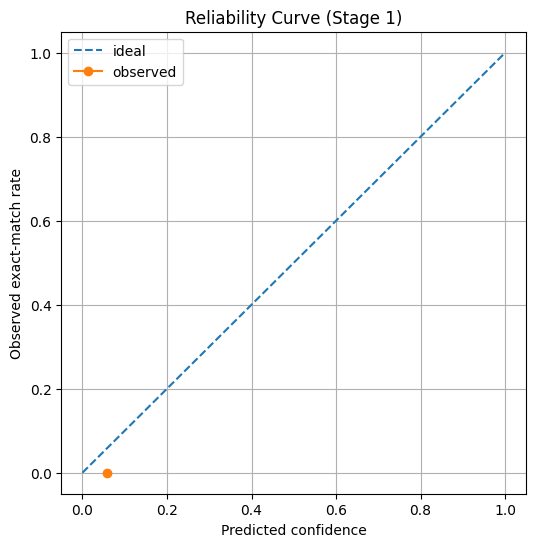

Isotonic calibration fitted.


In [16]:
pred_df['is_exact'] = (pred_df['cer'] == 0.0).astype(float)

corr = pred_df['sequence_confidence'].corr(pred_df['cer'], method='spearman')
print(f'Spearman(confidence, CER): {corr:.4f}')

# Reliability curve bins
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
pred_df['conf_bin'] = pd.cut(pred_df['sequence_confidence'], bins=bins, include_lowest=True)
rel = pred_df.groupby('conf_bin', observed=False).agg(
    avg_conf=('sequence_confidence', 'mean'),
    acc=('is_exact', 'mean'),
    n=('clip_id', 'count'),
).reset_index(drop=True)

rel = rel.dropna()
if len(rel) > 0:
    ece = np.sum(np.abs(rel['avg_conf'] - rel['acc']) * (rel['n'] / rel['n'].sum()))
else:
    ece = np.nan
print(f'ECE (exact-match proxy): {ece:.4f}')

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], '--', label='ideal')
if len(rel) > 0:
    plt.plot(rel['avg_conf'], rel['acc'], marker='o', label='observed')
plt.xlabel('Predicted confidence')
plt.ylabel('Observed exact-match rate')
plt.title('Reliability Curve (Stage 1)')
plt.legend()
plt.grid(True)
plt.show()

# Optional isotonic calibration if sklearn available
if IsotonicRegression is not None and len(pred_df) >= 20:
    iso = IsotonicRegression(out_of_bounds='clip')
    x = pred_df['sequence_confidence'].to_numpy()
    y = pred_df['is_exact'].to_numpy()
    iso.fit(x, y)
    pred_df['sequence_conf_calibrated'] = iso.predict(x)
    print('Isotonic calibration fitted.')
else:
    pred_df['sequence_conf_calibrated'] = pred_df['sequence_confidence']
    print('Isotonic not available or insufficient data; using raw confidence.')

## 8. Error Bucketing for Stage 1 Failures

We group failures by confidence, sequence length, and speaker to expose where Stage 1 breaks.

In [ ]:
# Attach frame lengths for analysis
val_len_map = {row['clip_id']: np.load(LIP_ROI_DIR / row['speaker_id'] / f"{row['clip_id']}.npz")['mouth_rois'].shape[0]
               for _, row in val_df.iterrows()}
pred_df['n_frames'] = pred_df['clip_id'].map(val_len_map)

# Buckets
pred_df['len_bucket'] = pd.cut(pred_df['n_frames'], bins=[0, 60, 100, 160, 10_000], labels=['short', 'mid', 'long', 'xlong'])
pred_df['conf_bucket'] = pd.cut(pred_df['sequence_confidence'], bins=[0.0, 0.4, 0.6, 0.8, 1.0], labels=['very_low', 'low', 'mid', 'high'], include_lowest=True)
pred_df['high_cer'] = pred_df['cer'] >= pred_df['cer'].quantile(0.75)

bucket_summary = pred_df.groupby(['speaker_id', 'len_bucket', 'conf_bucket'], observed=False).agg(
    n=('clip_id', 'count'),
    avg_wer=('wer', 'mean'),
    avg_cer=('cer', 'mean')
).reset_index().sort_values(['avg_wer', 'n'], ascending=[False, False])

display(bucket_summary.head(30))

error_buckets_path = OUTPUT_DIR / 'stage1_error_buckets.csv'
bucket_summary.to_csv(error_buckets_path, index=False)
print('Saved:', error_buckets_path)

## 9. Quick Fine-Tuning Experiment (Optional)

This short experiment compares:

- pretrained-only
- head-only tuning
- full model tuning

Set `RUN_FINETUNE = True` only if a compatible pretrained checkpoint was loaded and GPU is available.

In [ ]:
RUN_FINETUNE = False
MAX_STEPS = 80
LR = 2e-4

ctc_loss_fn = nn.CTCLoss(blank=blank_id, zero_infinity=True)


def train_one_epoch_stage1(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, max_steps: int = 80):
    model.train()
    losses = []
    step = 0
    for batch in loader:
        rois = batch['rois'].to(DEVICE)
        roi_lens = batch['roi_lens'].to(DEVICE)
        tgt = batch['token_ids'].to(DEVICE)
        tgt_lens = batch['token_lens'].to(DEVICE)

        logits = model(rois, roi_lens)  # (B,T,V)
        log_probs = F.log_softmax(logits, dim=-1).transpose(0, 1)  # (T,B,V)

        input_lens = roi_lens
        targets_flat = torch.cat([tgt[i, :tgt_lens[i]] for i in range(tgt.size(0))])

        loss = ctc_loss_fn(log_probs, targets_flat, input_lens, tgt_lens)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        losses.append(float(loss.item()))
        step += 1
        if step >= max_steps:
            break

    return float(np.mean(losses)) if losses else np.nan


if RUN_FINETUNE:
    for name, p in model.named_parameters():
        p.requires_grad = True

    # Example freeze plan: only CTC head + transformer
    # for name, p in model.named_parameters():
    #     if not (name.startswith('temporal_encoder') or name.startswith('ctc_head') or name.startswith('proj')):
    #         p.requires_grad = False

    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
    train_loss = train_one_epoch_stage1(model, train_loader, optimizer, max_steps=MAX_STEPS)
    print(f'Quick fine-tune train loss: {train_loss:.4f}')

    tuned_ckpt = OUTPUT_DIR / 'stage1_quick_finetuned.pt'
    torch.save({'model_state_dict': model.state_dict()}, tuned_ckpt)
    print('Saved quick tuned checkpoint:', tuned_ckpt)
else:
    print('RUN_FINETUNE=False, skipped quick tuning experiment.')

## 10. Retrain-vs-Reuse Decision Matrix and Next Actions

Use measured metrics + calibration quality to choose one path:

- **Reuse pretrained** if WER/CER are already acceptable and confidence is calibrated.
- **Fine-tune** if model is close but domain mismatch remains.
- **Retrain** if performance is poor or no compatible checkpoint can be loaded.

This section also exports Stage 2-required fields:

- `clip_id`
- `predicted_tokens`
- `token_confidence`
- optional `visual_embedding_path` (placeholder)

In [ ]:
def decide_action(wer: float, cer: float, ece_value: float, loaded_checkpoint: bool) -> str:
    # You can tighten/relax these thresholds for your project goals.
    if loaded_checkpoint and wer <= 0.35 and cer <= 0.20 and (np.isnan(ece_value) or ece_value <= 0.12):
        return 'reuse_pretrained'
    if loaded_checkpoint and wer <= 0.65:
        return 'finetune'
    return 'retrain'


loaded_checkpoint = load_report is not None
action = decide_action(overall_wer, overall_cer, ece, loaded_checkpoint)
print('Decision:', action)

if action == 'reuse_pretrained':
    rationale = 'Pretrained Stage 1 is already within target range on validation.'
elif action == 'finetune':
    rationale = 'Checkpoint is promising but domain mismatch remains; run focused fine-tuning.'
else:
    rationale = 'No compatible/strong checkpoint behavior; retrain Stage 1 with stronger supervision and augmentation.'

print('Rationale:', rationale)

# Stage-2 handoff export
handoff = pred_df[['clip_id', 'pred_token_ids', 'token_confidence', 'sequence_conf_calibrated']].copy()
handoff = handoff.rename(columns={
    'pred_token_ids': 'predicted_tokens',
    'sequence_conf_calibrated': 'token_confidence_calibrated',
})
handoff['visual_embedding_path'] = ''

handoff_path = OUTPUT_DIR / 'stage1_outputs_for_stage2.csv'
handoff.to_csv(handoff_path, index=False)
print('Saved Stage-2 handoff:', handoff_path)

summary = {
    'overall_wer': float(overall_wer),
    'overall_cer': float(overall_cer),
    'ece': None if np.isnan(ece) else float(ece),
    'loaded_checkpoint': bool(loaded_checkpoint),
    'decision': action,
    'rationale': rationale,
}
summary_path = OUTPUT_DIR / 'stage1_decision_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))
print('Saved summary:', summary_path)
summary